# MovieLens 1M Matrix Factorization

This audit-oriented notebook reads the split files, trained model outputs,
metrics, and interpretability reports produced by `python -m scripts.run_pipeline`.
It does not rerun SVD/PMF training or tuning.

## 1. Project goal

Compare a local benchmark collaborative-filtering baseline with two
matrix-factorization models on the same deterministic MovieLens 1M split,
then inspect both global PMF latent-factor behavior and local recommendation
explanations for three audit users.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from models.pmf_model import PMFModel
from utils.data_loader import load_movielens
from utils.matrix_creation import load_mappings

ROOT = Path.cwd()
REPORTS = ROOT / "reports"
PROCESSED = ROOT / "processed"

with (REPORTS / "model_metrics.json").open(encoding="utf-8") as handle:
    metrics = json.load(handle)
with (REPORTS / "baseline_tuning.json").open(encoding="utf-8") as handle:
    baseline_tuning = json.load(handle)
with (REPORTS / "evaluated_users.json").open(encoding="utf-8") as handle:
    evaluated_users = json.load(handle)

data = load_movielens(ROOT / "data")
train = pd.read_csv(PROCESSED / "train_ratings.csv")
validation = pd.read_csv(PROCESSED / "validation_ratings.csv")
test = pd.read_csv(PROCESSED / "test_ratings.csv")
factor_interpretation = pd.read_csv(REPORTS / "pmf_factor_interpretation.csv")
factor_genre_profiles = pd.read_csv(REPORTS / "pmf_factor_genre_profiles.csv")
similarities = pd.read_csv(REPORTS / "pmf_movie_similarities.csv")
user_to_index, movie_to_index, index_to_user, index_to_movie = load_mappings(
    PROCESSED / "mappings"
)
pmf = PMFModel.load(REPORTS / "pmf_factors")

print(f"Ratings: {len(data.ratings):,}")
print(
    f"Split: train={len(train):,}, validation={len(validation):,}, "
    f"test={len(test):,}"
)
print(f"Mapped users={len(user_to_index):,}, mapped movies={len(movie_to_index):,}")

Ratings: 1,000,209
Split: train=705,806, validation=147,201, test=147,202
Mapped users=6,040, mapped movies=3,706


## 2. MovieLens EDA and insights

The compact EDA below focuses on audit-relevant properties: rating skew,
uneven user activity, long-tail movie popularity, sparsity, and genre frequency.
These properties motivate regularization and a reproducible user-level split.

,metric,value
0,ratings,1.000209e+06
1,users,6.040000e+03
2,movies,3.883000e+03
3,matrix_sparsity,9.573532e-01
4,median_user_activity,9.600000e+01
5,median_movie_popularity,1.235000e+02


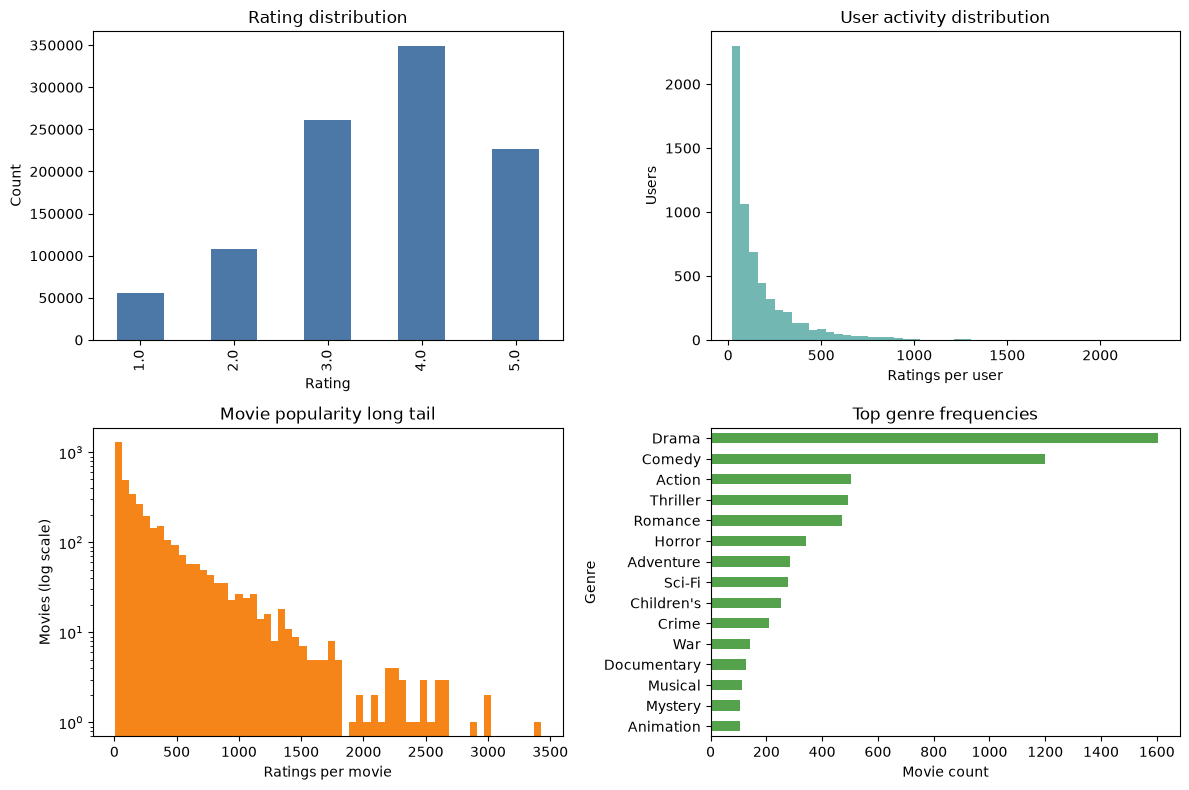

In [2]:
rating_counts = data.ratings["rating"].value_counts().sort_index()
user_activity = data.ratings.groupby("user_id").size()
movie_popularity = data.ratings.groupby("movie_id").size()
movie_genres = data.movies.assign(
    genre=data.movies["genres"].str.split("|")
).explode("genre")
genre_counts = movie_genres["genre"].value_counts().head(15)
sparsity = 1.0 - len(data.ratings) / (
    data.users["user_id"].nunique() * data.movies["movie_id"].nunique()
)
summary = pd.DataFrame(
    [
        {"metric": "ratings", "value": len(data.ratings)},
        {"metric": "users", "value": data.users["user_id"].nunique()},
        {"metric": "movies", "value": data.movies["movie_id"].nunique()},
        {"metric": "matrix_sparsity", "value": sparsity},
        {"metric": "median_user_activity", "value": user_activity.median()},
        {"metric": "median_movie_popularity", "value": movie_popularity.median()},
    ]
)
display(summary)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
rating_counts.plot(kind="bar", ax=axes[0, 0], color="#4c78a8")
axes[0, 0].set(title="Rating distribution", xlabel="Rating", ylabel="Count")
axes[0, 1].hist(user_activity, bins=50, color="#72b7b2")
axes[0, 1].set(
    title="User activity distribution",
    xlabel="Ratings per user",
    ylabel="Users",
)
axes[1, 0].hist(movie_popularity, bins=60, color="#f58518", log=True)
axes[1, 0].set(
    title="Movie popularity long tail",
    xlabel="Ratings per movie",
    ylabel="Movies (log scale)",
)
genre_counts.sort_values().plot(kind="barh", ax=axes[1, 1], color="#54a24b")
axes[1, 1].set(title="Top genre frequencies", xlabel="Movie count", ylabel="Genre")
fig.tight_layout()
plt.show()

Ratings are skewed toward higher values: ratings 4 and 5 account for a
large share of all observations. The user-item matrix is highly sparse,
movie popularity has a pronounced long tail, and user activity is
heterogeneous. Low-support movies are harder to model because they provide
fewer observed residuals or item-factor updates. These data properties make
regularization and a reproducible user-level split necessary for stable
evaluation.

## 3. Reproducible split

The project uses a deterministic interaction-level split grouped by user.
Every mapped user and held-out movie remains covered by training rows, while
validation and test rows stay disjoint from train and from each other.

In [3]:
split_table = pd.DataFrame(
    [
        {"split": "train", "rows": len(train)},
        {"split": "validation", "rows": len(validation)},
        {"split": "test", "rows": len(test)},
    ]
)
display(split_table)
print(metrics["split"])

,split,rows
0,train,705806
1,validation,147201
2,test,147202


{'train_ratio': 0.7, 'validation_ratio': 0.15, 'test_ratio': 0.15, 'actual_counts': {'train': 705806, 'validation': 147201, 'test': 147202}}


## 4. Benchmark collaborative filtering model

The benchmark is a local regularized bias-only collaborative filtering model,
not a third-party recommender library. It predicts `global_mean + user_bias +
item_bias`, learns only from observed ratings, selects regularization on
validation, then refits once on train plus validation before a single test
evaluation.

In [4]:
baseline_results = pd.DataFrame(baseline_tuning["results"])
display(baseline_results)
print("Selected baseline:", baseline_tuning["selected"])
print("Test RMSE:", metrics["Baseline_CF_RMSE"])

,user_regularization,item_regularization,n_iterations,validation_mse,validation_rmse
0,1.0,1.0,20,0.820027,0.905553
1,2.0,2.0,20,0.819857,0.905459
2,5.0,5.0,20,0.820151,0.905622
3,10.0,10.0,20,0.821857,0.906564
4,20.0,20.0,20,0.827044,0.909419
5,40.0,40.0,20,0.839119,0.916034
6,80.0,80.0,20,0.862262,0.928581


Selected baseline: {'user_regularization': 2.0, 'item_regularization': 2.0, 'n_iterations': 20, 'validation_mse': 0.8198565204045031, 'validation_rmse': 0.9054592869944529}
Test RMSE: 0.9078097662922908


## 5. SVD methodology and tuning

The SVD model factorizes a user-mean-centered sparse matrix with a regularized
item residual bias. Tuning uses validation rows only; final predictions are
stored raw and unclipped for ranking, with clipping used only for
evaluation/display.

In [5]:
svd_tuning = pd.read_json(REPORTS / "svd_tuning.json")
display(svd_tuning.sort_values("validation_rmse").head(10))
print("Selected SVD params:", metrics["svd_best_params"])

,n_factors,item_bias_regularization,validation_rmse
7,20,5,0.896209
2,20,0,0.896270
12,20,10,0.896792
8,40,5,0.897119
3,40,0,0.897152
13,40,10,0.897733
17,20,20,0.898262
6,10,5,0.898446
1,10,0,0.898577
11,10,10,0.898989


Selected SVD params: {'n_factors': 20, 'item_bias_regularization': 5.0}


## 6. PMF methodology and tuning

PMF is a locally implemented biased matrix factorization model trained with
SGD. The current stable grid is intentionally preserved: factors 96/112/128,
learning rate 0.006, factor regularization 0.05/0.06/0.07, and bias
regularization 0.02.

In [6]:
pmf_tuning = pd.read_json(REPORTS / "pmf_tuning.json")
display(pmf_tuning.sort_values("validation_rmse"))
print("Selected PMF params:", metrics["pmf_best_params"])

,n_factors,learning_rate,factor_regularization,bias_regularization,best_epoch,validation_rmse,epochs_run,seconds,hit_epoch_cap,hit_factor_boundary
7,128,0.006,0.06,0.02,53,0.849353,61,32.477,False,True
6,128,0.006,0.05,0.02,40,0.849747,48,24.422,False,True
4,112,0.006,0.06,0.02,53,0.849830,61,26.968,False,False
1,96,0.006,0.06,0.02,53,0.850033,61,24.845,False,False
8,128,0.006,0.07,0.02,68,0.850417,70,35.468,False,True
3,112,0.006,0.05,0.02,41,0.850464,49,21.800,False,False
5,112,0.006,0.07,0.02,68,0.850715,70,30.822,False,False
0,96,0.006,0.05,0.02,40,0.850756,48,20.907,False,False
2,96,0.006,0.07,0.02,68,0.850899,70,26.618,False,False


Selected PMF params: {'n_factors': 128, 'learning_rate': 0.006, 'factor_regularization': 0.06, 'bias_regularization': 0.02, 'selected_epoch': 53, 'validation_rmse': 0.8493525385856628}


## 7. Convergence, regularization and stopping

The selected PMF configuration is 128 factors, learning rate 0.006, factor
regularization 0.06, and bias regularization 0.02. Validation RMSE reaches
its minimum at selected epoch 53. With patience 8, tuning for that
configuration stops after 61 epochs. The final refit uses exactly 53 epochs
on train plus validation and does not use the test set for stopping. The
selected epoch is not at the 70-epoch boundary, while the selected factor
count is at the searched factor boundary; that boundary result is disclosed
as a limitation, not retuned here.

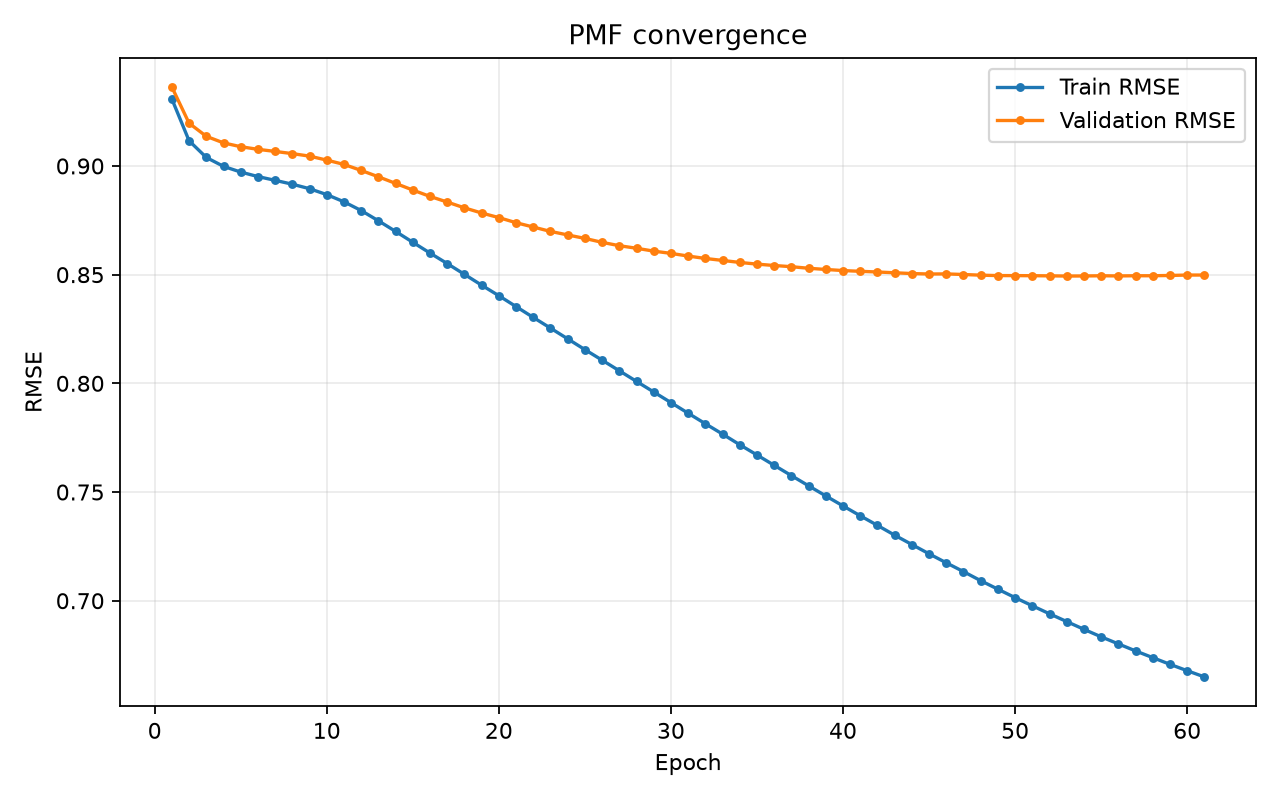

Final refit epochs: 53
Final history validation values: [None]
Search diagnostics: {'selected_at_factor_boundary': True, 'selected_at_epoch_boundary': False, 'selected_early_stopping_triggered': True, 'search_max_factors': 128, 'search_max_epochs': 70}


In [7]:
display(Image(filename=str(REPORTS / "pmf_convergence.png")))
pmf_metadata = json.loads(
    (REPORTS / "pmf_factors" / "metadata.json").read_text(encoding="utf-8")
)
print("Final refit epochs:", pmf_metadata["config"]["epochs"])
print(
    "Final history validation values:",
    sorted({row["validation_rmse"] for row in pmf_metadata["history"]}),
)
print("Search diagnostics:", metrics["pmf_search_diagnostics"])

## 8. Test metrics and benchmark comparison

All three models are evaluated on the same held-out test rows. Both
matrix-factorization models beat the bias-only benchmark, and PMF also
improves over SVD.

,model,mse,rmse
0,Baseline CF,0.824119,0.907810
1,SVD,0.793518,0.890796
2,PMF,0.712165,0.843899


SVD vs baseline improvement: 1.874%
PMF vs baseline improvement: 7.040%
PMF vs SVD improvement: 5.265%


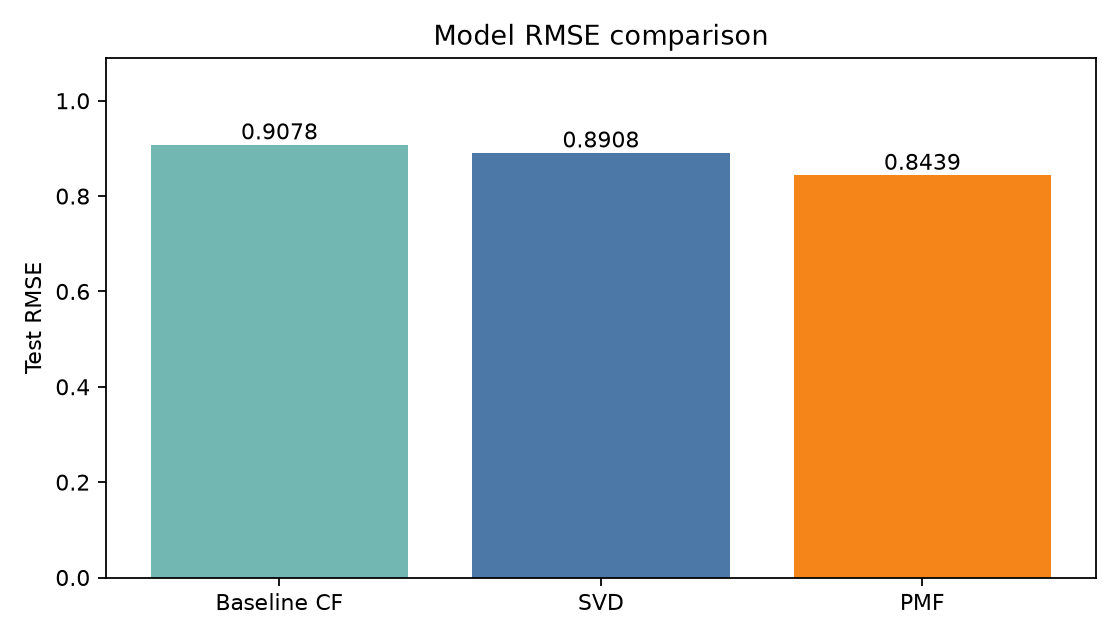

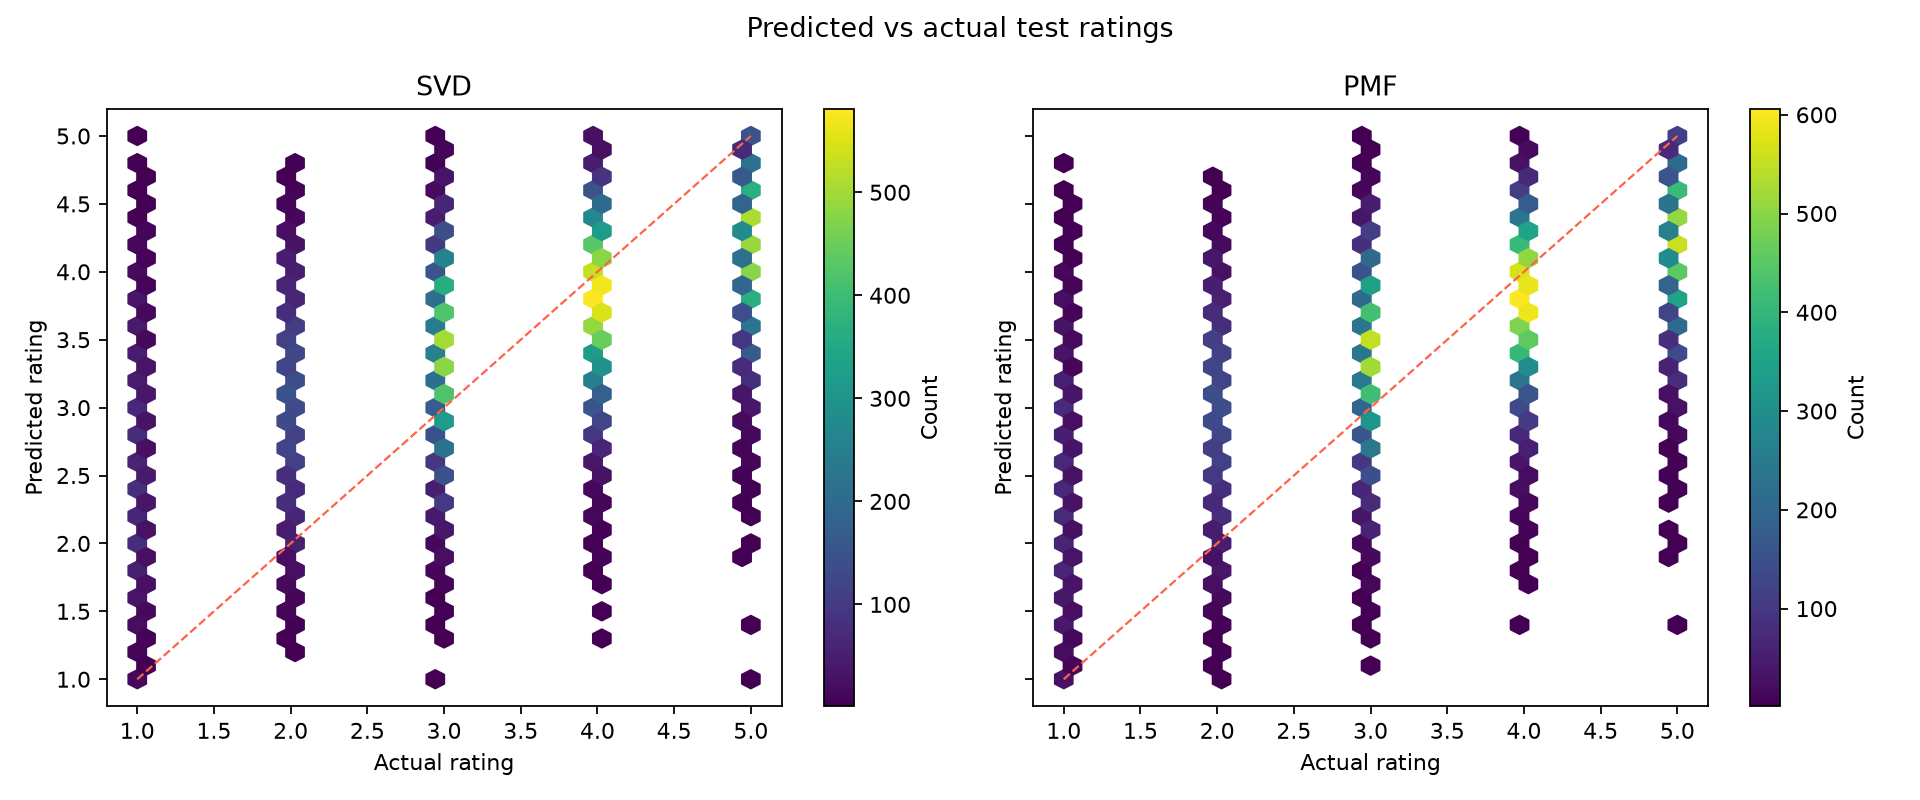

In [8]:
metric_table = pd.DataFrame(
    [
        {
            "model": "Baseline CF",
            "mse": metrics["Baseline_CF_MSE"],
            "rmse": metrics["Baseline_CF_RMSE"],
        },
        {"model": "SVD", "mse": metrics["SVD_MSE"], "rmse": metrics["SVD_RMSE"]},
        {"model": "PMF", "mse": metrics["PMF_MSE"], "rmse": metrics["PMF_RMSE"]},
    ]
)
display(metric_table)
print(f"SVD vs baseline improvement: {metrics['SVD_vs_Baseline_improvement_%']:.3f}%")
print(f"PMF vs baseline improvement: {metrics['PMF_vs_Baseline_improvement_%']:.3f}%")
print(f"PMF vs SVD improvement: {metrics['PMF_vs_SVD_improvement_%']:.3f}%")
display(Image(filename=str(REPORTS / "rmse_comparison.png")))
display(Image(filename=str(REPORTS / "predicted_vs_actual.png")))

## 9. Global latent factor interpretation

The PMF item-factor analysis selects the top five factors by variance across
item loadings. A factor's sign is arbitrary: positive and negative poles can
be flipped without changing the model if the corresponding user factor is
flipped too. The label or theme of a factor is therefore a descriptive
interpretation from movies and genres on both poles, not ground truth
semantics.

,factor_index,factor_variance,polarity,polarity_rank,movie_id,title,genres,factor_loading
0,123,0.017044,positive,1,3688,Porky's (1981),Comedy,0.644381
1,123,0.017044,positive,2,3431,Death Wish II (1982),Action|Drama,0.483069
2,123,0.017044,positive,3,3689,Porky's II: The Next Day (1983),Comedy,0.415265
3,123,0.017044,positive,4,1855,Krippendorf's Tribe (1998),Comedy,0.411035
4,123,0.017044,positive,5,3433,Death Wish 4: The Crackdown (1987),Action|Drama,0.402932
5,123,0.017044,positive,6,2411,Rocky IV (1985),Action|Drama,0.400579
6,123,0.017044,positive,7,2961,"Story of Us, The (1999)",Comedy|Drama,0.398805
7,123,0.017044,positive,8,3577,Two Moon Juction (1988),Drama,0.395567
8,123,0.017044,negative,1,2710,"Blair Witch Project, The (1999)",Horror,-0.496847
9,123,0.017044,negative,2,532,Serial Mom (1994),Comedy|Crime|Horror,-0.425156


,factor_index,polarity,genre,movie_count,genre_share,mean_factor_loading
0,10,negative,Horror,5,0.500000,-0.383474
1,10,negative,Drama,2,0.200000,-0.462993
2,10,negative,Crime,1,0.100000,-0.384618
3,10,negative,Sci-Fi,1,0.100000,-0.422868
4,10,negative,Thriller,1,0.100000,-0.384618
5,10,positive,Comedy,8,0.500000,0.457878
6,10,positive,Romance,3,0.187500,0.485245
7,10,positive,Drama,2,0.125000,0.447801
8,10,positive,Action,1,0.062500,0.450484
9,10,positive,Documentary,1,0.062500,0.432814


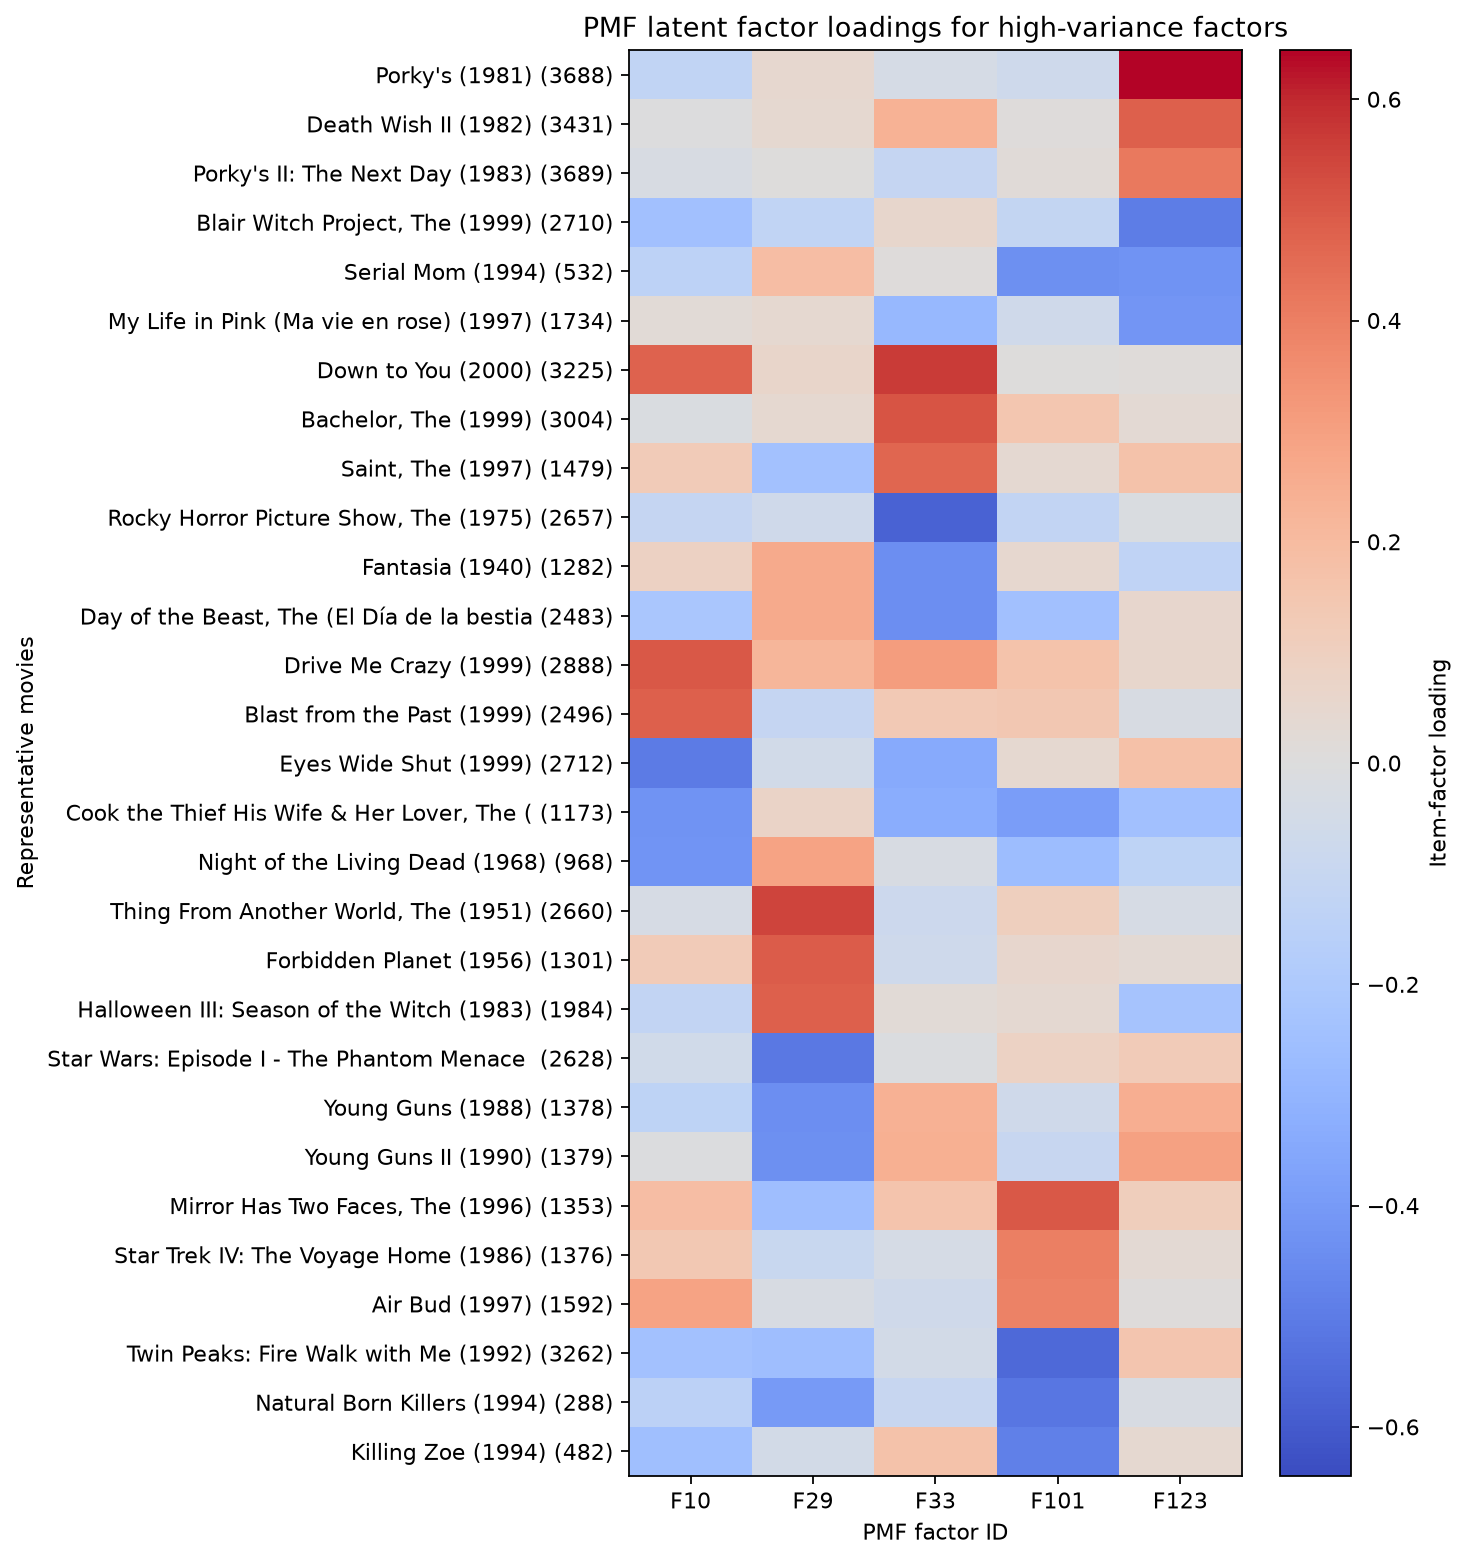

In [9]:
display(factor_interpretation.head(20))
display(factor_genre_profiles.head(20))
display(Image(filename=str(REPORTS / "pmf_latent_factor_heatmap.png")))

## 10. Movie similarity analysis

Cosine similarity is computed between PMF item-factor vectors. Anchor movies
are selected deterministically from popular mapped movies while encouraging
genre diversity. Self-matches are excluded and ties are broken by similarity
descending, then movie ID ascending.

In [10]:
display(similarities.head(30))
print(
    "Similarity range:",
    similarities["cosine_similarity"].min(),
    similarities["cosine_similarity"].max(),
)

,anchor_movie_id,anchor_title,anchor_genres,similar_movie_id,similar_title,similar_genres,cosine_similarity,rank
0,2858,American Beauty (1999),Comedy|Drama,1617,L.A. Confidential (1997),Crime|Film-Noir|Mystery|Thriller,0.544902,1
1,2858,American Beauty (1999),Comedy|Drama,1222,Full Metal Jacket (1987),Action|Drama|War,0.535649,2
2,2858,American Beauty (1999),Comedy|Drama,296,Pulp Fiction (1994),Crime|Drama,0.520803,3
3,2858,American Beauty (1999),Comedy|Drama,1728,"Winter Guest, The (1997)",Drama,0.513478,4
4,2858,American Beauty (1999),Comedy|Drama,2997,Being John Malkovich (1999),Comedy,0.494339,5
5,2858,American Beauty (1999),Comedy|Drama,50,"Usual Suspects, The (1995)",Crime|Thriller,0.489682,6
6,2858,American Beauty (1999),Comedy|Drama,3317,Wonder Boys (2000),Comedy|Drama,0.478323,7
7,2858,American Beauty (1999),Comedy|Drama,1673,Boogie Nights (1997),Drama,0.473511,8
8,2858,American Beauty (1999),Comedy|Drama,3949,Requiem for a Dream (2000),Drama,0.469242,9
9,2858,American Beauty (1999),Comedy|Drama,3171,Room at the Top (1959),Drama,0.465240,10


Similarity range: 0.439644473662361 0.9368732065528416


## 11. Three audit users

The split is interaction-level, so the selected users can have train,
validation, and test rows simultaneously. The two training-profile users are
selected from supported users near lower and upper quartiles of per-user PMF
test RMSE. The third user is a separate deterministic test case.

In [11]:
evaluated = pd.DataFrame(evaluated_users)
display(evaluated)

,user_id,role,selection_reason,train_ratings,validation_ratings,test_ratings,svd_test_rmse,pmf_test_rmse
0,3233,train_profile_accurate,Eligible user nearest the lower-quartile PMF t...,113,24,24,0.719702,0.692820
1,119,train_profile_less_accurate,Eligible user nearest the upper-quartile PMF t...,75,15,15,0.850408,0.940119
2,133,test_case,Separate deterministic test case near the medi...,120,25,25,1.094226,1.008767


## 12. Accurate vs less accurate user analysis

The comparison below uses train-history statistics and held-out test errors.
It avoids assuming that either user is train-only because the split is
interaction-level.

In [12]:
movies = data.movies[["movie_id", "title", "genres"]]
movie_popularity = data.ratings.groupby("movie_id").size().rename("movie_popularity")

def genre_entropy(frame):
    genres = (
        frame.merge(movies, on="movie_id", how="left")["genres"]
        .str.split("|")
        .explode()
    )
    shares = genres.value_counts(normalize=True)
    if shares.empty:
        return 0.0
    return float(-(shares * np.log2(shares)).sum())

def profile_stats(user_id):
    train_user = train.loc[train["user_id"].eq(user_id)].copy()
    test_user = test.loc[test["user_id"].eq(user_id)].copy()
    popularity = train_user.merge(
        movie_popularity, on="movie_id", how="left"
    )["movie_popularity"]
    return {
        "user_id": user_id,
        "train_interactions": len(train_user),
        "test_interactions": len(test_user),
        "train_mean_rating": train_user["rating"].mean(),
        "test_mean_rating": test_user["rating"].mean(),
        "train_high_rating_share": train_user["rating"].ge(4).mean(),
        "test_high_rating_share": test_user["rating"].ge(4).mean(),
        "genre_entropy": genre_entropy(train_user),
        "avg_train_movie_popularity": popularity.mean(),
        "distinct_train_movies": train_user["movie_id"].nunique(),
        "rating_distribution": train_user["rating"].value_counts().sort_index().to_dict(),
    }

profile_roles = evaluated.loc[
    evaluated["role"].isin(
        ["train_profile_accurate", "train_profile_less_accurate"]
    )
]
profile_table = profile_roles.merge(
    pd.DataFrame(
        [profile_stats(int(user_id)) for user_id in profile_roles["user_id"]]
    ),
    on="user_id",
    how="left",
)
display(profile_table)

for row in profile_roles.itertuples(index=False):
    recs = pd.read_csv(REPORTS / f"user_{int(row.user_id)}_recommendations.csv")
    explanations = pd.read_csv(
        REPORTS / f"user_{int(row.user_id)}_explanations.csv"
    )
    print(f"\n{row.role}: user {int(row.user_id)}")
    display(
        recs.dropna(subset=["pmf_rank"])
        .sort_values("pmf_rank")
        .head(5)[
            ["movie_id", "title", "genres", "pmf_ranking_score", "pmf_rank"]
        ]
    )
    display(
        explanations.head(3)[
            [
                "recommendation_rank",
                "title",
                "raw_pmf_ranking_score",
                "nearest_known_title",
                "nearest_known_rating",
                "nearest_known_similarity",
                "common_genres",
            ]
        ]
    )

,user_id,role,selection_reason,train_ratings,validation_ratings,test_ratings,svd_test_rmse,pmf_test_rmse,train_interactions,test_interactions,train_mean_rating,test_mean_rating,train_high_rating_share,test_high_rating_share,genre_entropy,avg_train_movie_popularity,distinct_train_movies,rating_distribution
0,3233,train_profile_accurate,Eligible user nearest the lower-quartile PMF t...,113,24,24,0.719702,0.692820,113,24,4.079646,4.291667,0.805310,0.916667,3.175745,816.469027,113,"{2.0: 5, 3.0: 17, 4.0: 55, 5.0: 36}"
1,119,train_profile_less_accurate,Eligible user nearest the upper-quartile PMF t...,75,15,15,0.850408,0.940119,75,15,3.613333,3.200000,0.506667,0.400000,3.213763,690.680000,75,"{2.0: 7, 3.0: 30, 4.0: 23, 5.0: 15}"



train_profile_accurate: user 3233


,movie_id,title,genres,pmf_ranking_score,pmf_rank
6,2503,"Apple, The (Sib) (1998)",Drama,4.852531,1.0
4,3338,For All Mankind (1989),Documentary,4.733309,2.0
10,1207,To Kill a Mockingbird (1962),Drama,4.684510,3.0
11,1420,Message to Love: The Isle of Wight Festival (1...,Documentary,4.650956,4.0
12,1423,Hearts and Minds (1996),Drama,4.638249,5.0


,recommendation_rank,title,raw_pmf_ranking_score,nearest_known_title,nearest_known_rating,nearest_known_similarity,common_genres
0,1,"Apple, The (Sib) (1998)",4.852531,"Conversation, The (1974)",5.0,0.406896,Drama
1,2,For All Mankind (1989),4.733309,"Conversation, The (1974)",5.0,0.537081,NaN
2,3,To Kill a Mockingbird (1962),4.684510,Mr. Smith Goes to Washington (1939),4.0,0.564305,Drama



train_profile_less_accurate: user 119


,movie_id,title,genres,pmf_ranking_score,pmf_rank
0,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.904145,1.0
10,649,Cold Fever (Á köldum klaka) (1994),Comedy|Drama,4.849060,2.0
6,2905,Sanjuro (1962),Action|Adventure,4.820765,3.0
1,318,"Shawshank Redemption, The (1994)",Drama,4.710608,4.0
11,3851,I'm the One That I Want (2000),Comedy,4.696043,5.0


,recommendation_rank,title,raw_pmf_ranking_score,nearest_known_title,nearest_known_rating,nearest_known_similarity,common_genres
0,1,"Matrix, The (1999)",4.904145,X-Men (2000),5.0,0.416803,Action|Sci-Fi
1,2,Cold Fever (Á köldum klaka) (1994),4.849059,Teaching Mrs. Tingle (1999),4.0,0.372053,Comedy
2,3,Sanjuro (1962),4.820765,Mystery Men (1999),5.0,0.271237,Action|Adventure


User 3233 is the more accurate profile in this deterministic selection: PMF
test RMSE is 0.6928 versus 0.9401 for user 119. The available profile
statistics explain part of the difference: user 3233 has more train and test
support (113/24 versus 75/15), giving the model a broader observed profile
and a more stable held-out estimate. If genre entropy, high-rating share, or
popularity statistics do not fully separate the users, the difference should
be read as observed and only partially explained by these profile summaries
rather than as a universal rule.

## 13. Local recommendation explanations

Each audit user has a PMF local explanation artifact. The decomposition
reconstructs the raw PMF ranking score as `global_mean + user_bias +
item_bias + sum(user_factor[k] * item_factor[k])`. The nearest known liked
movie is searched in the user's full known history, preferring rating >= 4
when available.

User 3233 (train_profile_accurate) max reconstruction error: 0.00e+00


,recommendation_rank,title,raw_pmf_ranking_score,global_mean_contribution,user_bias_contribution,item_bias_contribution,total_latent_dot_product,nearest_known_title,nearest_known_similarity
0,1,"Apple, The (Sib) (1998)",4.852531,3.582113,0.029172,1.077698,0.163548,"Conversation, The (1974)",0.406896
1,2,For All Mankind (1989),4.733309,3.582113,0.029172,0.957516,0.164509,"Conversation, The (1974)",0.537081
2,3,To Kill a Mockingbird (1962),4.684510,3.582113,0.029172,0.850771,0.222454,Mr. Smith Goes to Washington (1939),0.564305
3,4,Message to Love: The Isle of Wight Festival (1...,4.650956,3.582113,0.029172,0.879125,0.160545,Rushmore (1998),0.492270
4,5,Hearts and Minds (1996),4.638249,3.582113,0.029172,0.802103,0.224861,"Soldier's Daughter Never Cries, A (1998)",0.575997


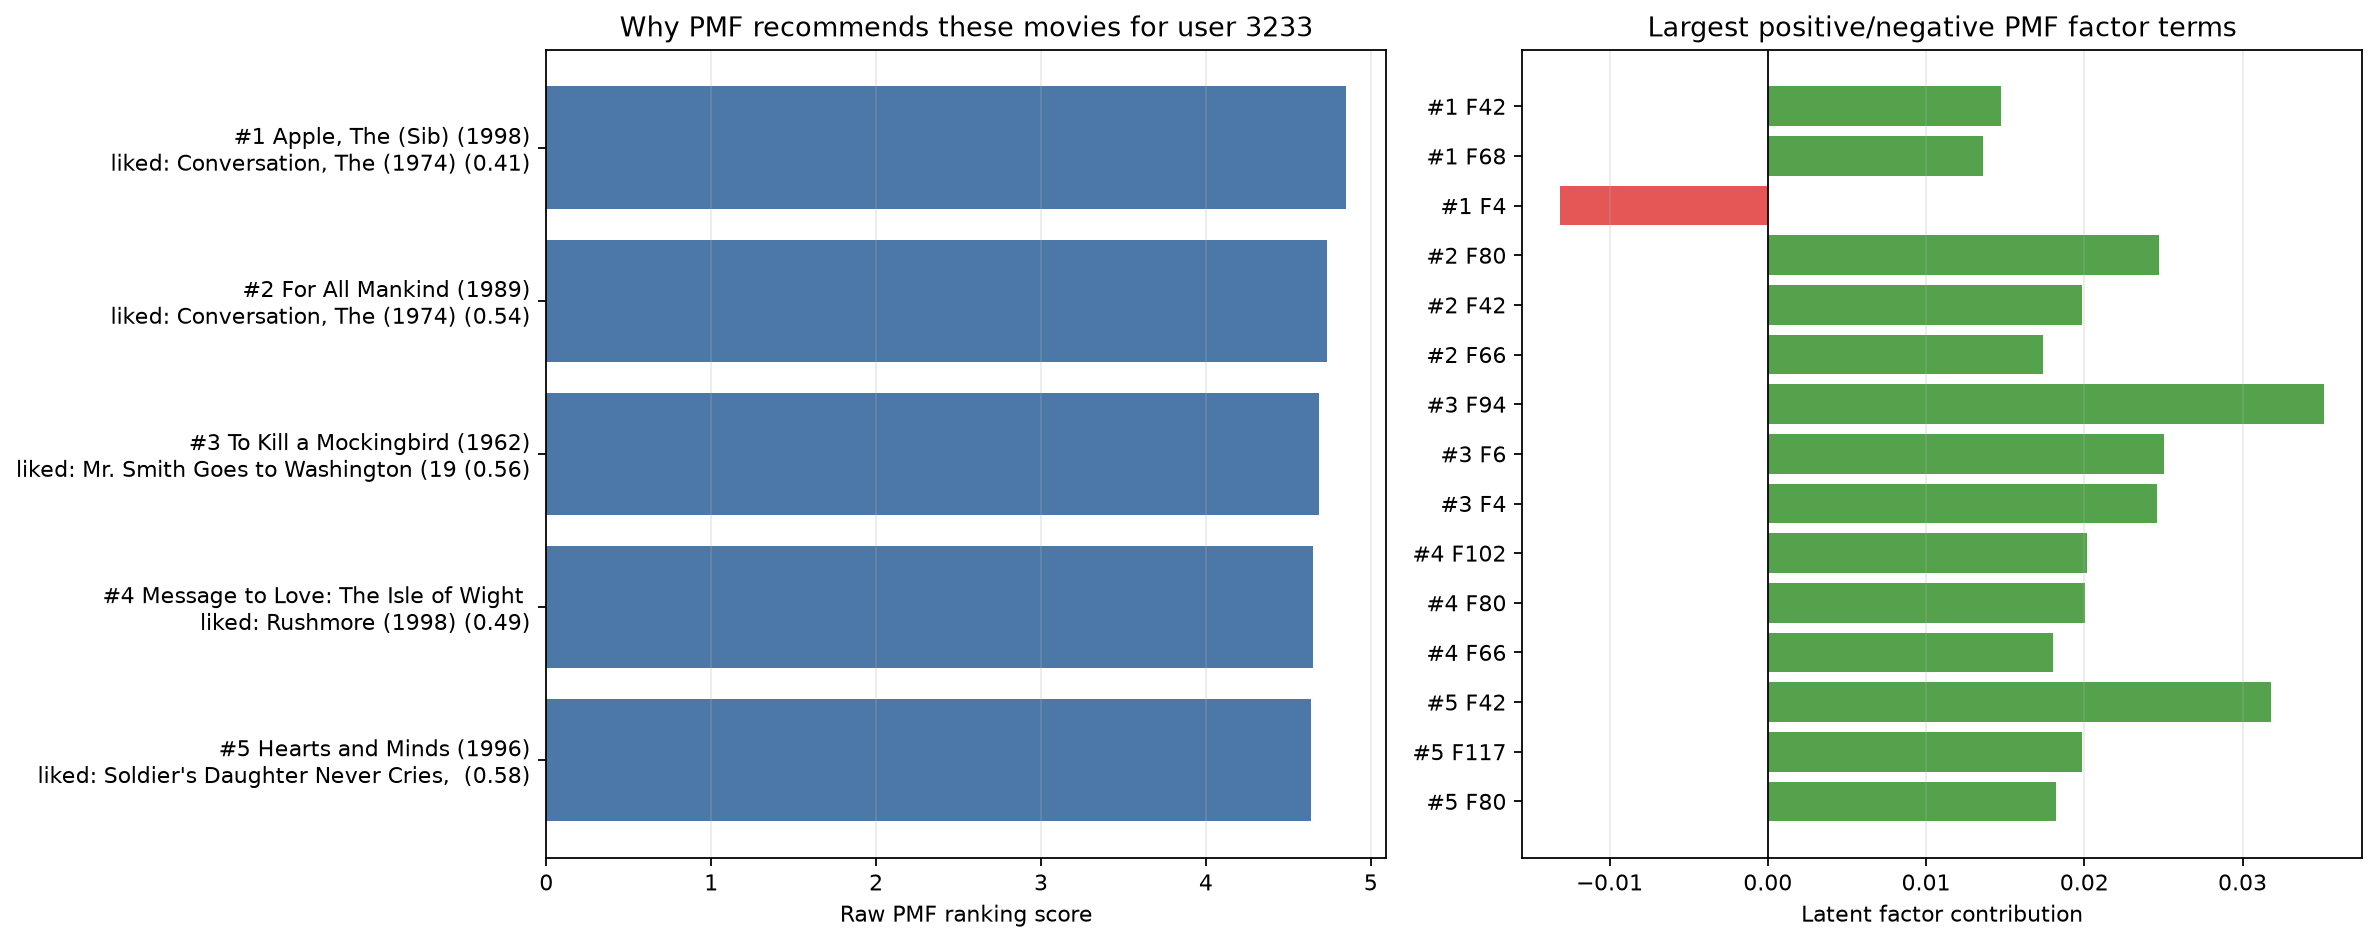

User 119 (train_profile_less_accurate) max reconstruction error: 0.00e+00


,recommendation_rank,title,raw_pmf_ranking_score,global_mean_contribution,user_bias_contribution,item_bias_contribution,total_latent_dot_product,nearest_known_title,nearest_known_similarity
0,1,"Matrix, The (1999)",4.904145,3.582113,0.14292,0.695491,0.483621,X-Men (2000),0.416803
1,2,Cold Fever (Á köldum klaka) (1994),4.849059,3.582113,0.14292,0.903767,0.220260,Teaching Mrs. Tingle (1999),0.372053
2,3,Sanjuro (1962),4.820765,3.582113,0.14292,1.048608,0.047123,Mystery Men (1999),0.271237
3,4,"Shawshank Redemption, The (1994)",4.710607,3.582113,0.14292,0.973373,0.012201,"Sixth Sense, The (1999)",0.432737
4,5,I'm the One That I Want (2000),4.696043,3.582113,0.14292,0.540305,0.430705,Jumpin' Jack Flash (1986),0.413574


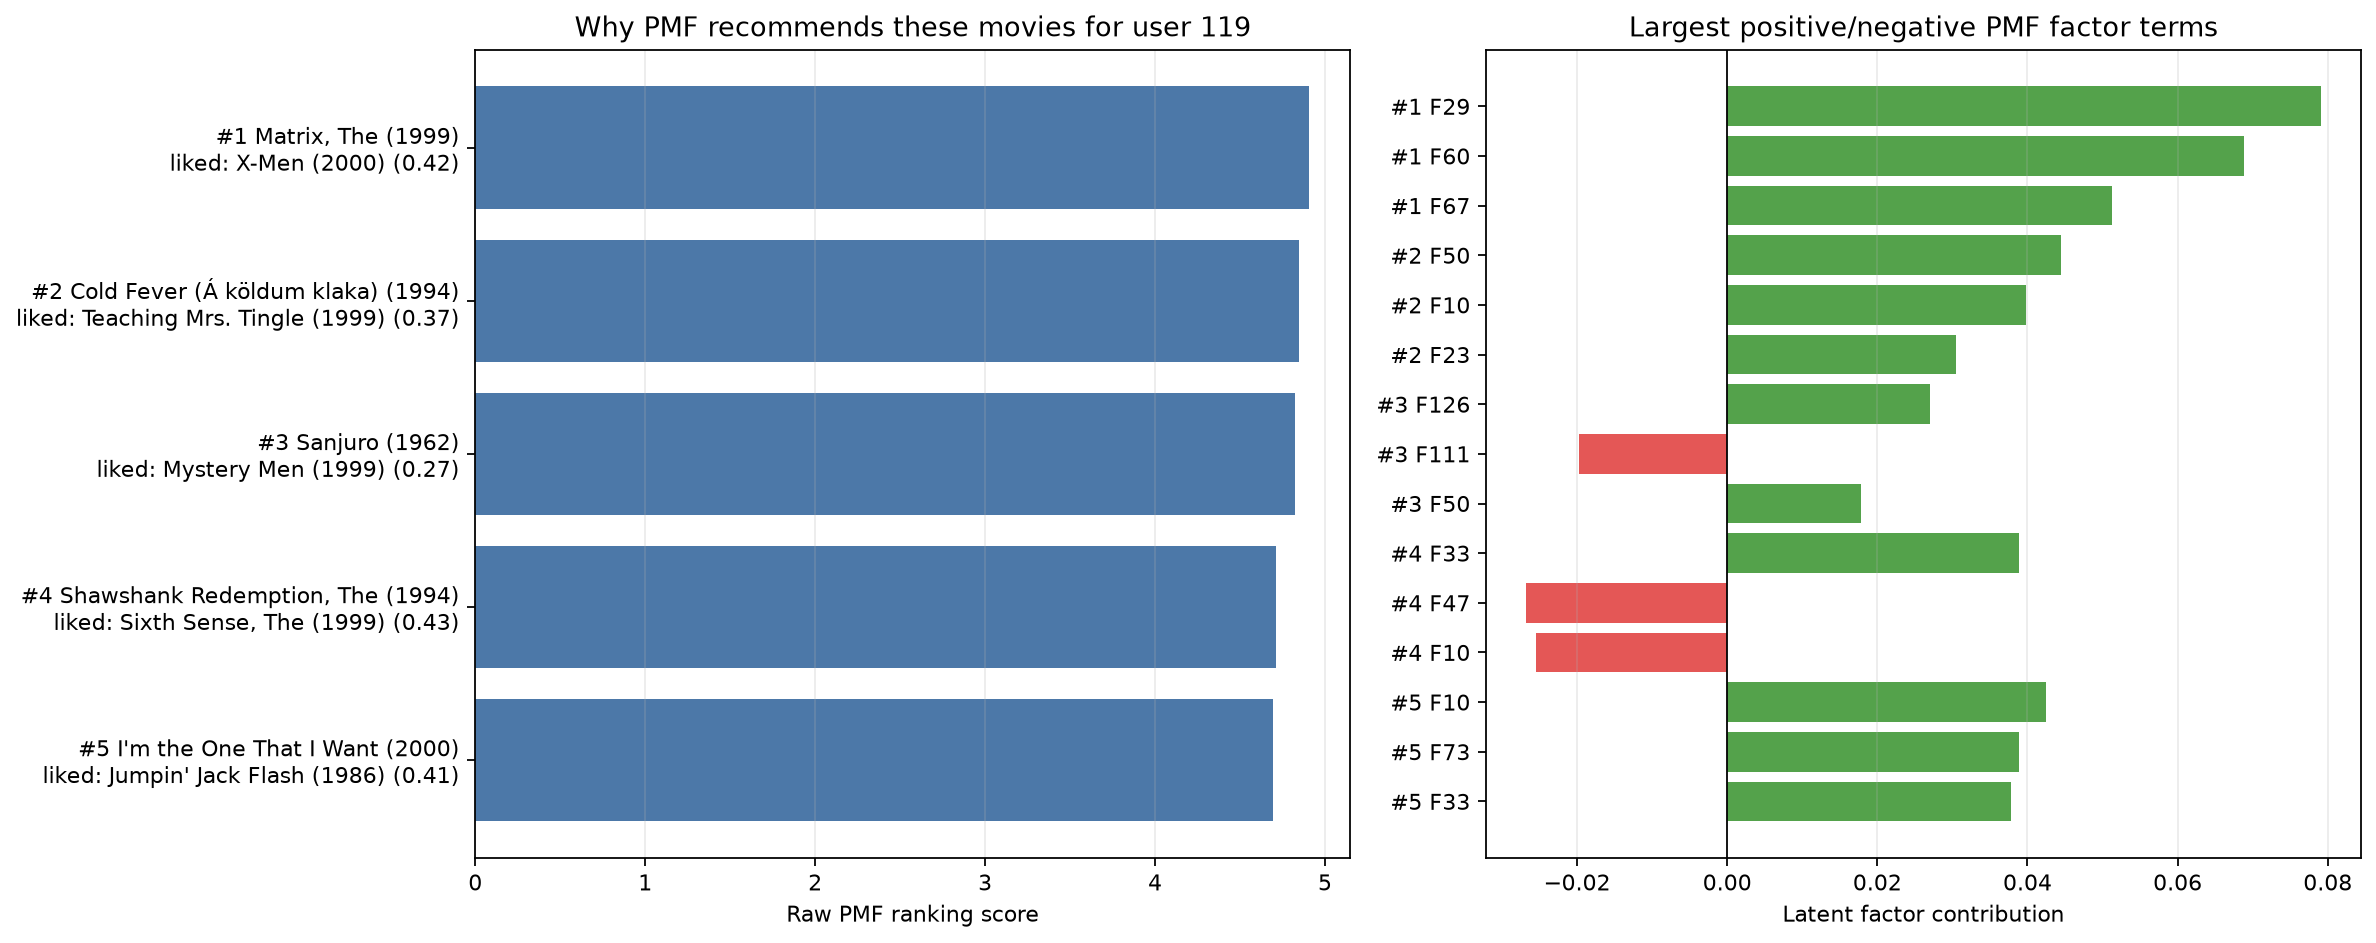

User 133 (test_case) max reconstruction error: 0.00e+00


,recommendation_rank,title,raw_pmf_ranking_score,global_mean_contribution,user_bias_contribution,item_bias_contribution,total_latent_dot_product,nearest_known_title,nearest_known_similarity
0,1,Burnt By the Sun (Utomlyonnye solntsem) (1994),4.945301,3.582113,0.000784,0.342137,1.020268,Welcome To Sarajevo (1997),0.443998
1,2,"Sound of Music, The (1965)",4.851778,3.582113,0.000784,0.299741,0.969140,Out of Africa (1985),0.434639
2,3,Firelight (1997),4.822846,3.582113,0.000784,0.693548,0.546402,St. Elmo's Fire (1985),0.485239
3,4,"King of Masks, The (Bian Lian) (1996)",4.771041,3.582113,0.000784,0.626218,0.561927,Ponette (1996),0.456301
4,5,Patch Adams (1998),4.754147,3.582113,0.000784,-0.536332,1.707583,I Dreamed of Africa (2000),0.627757


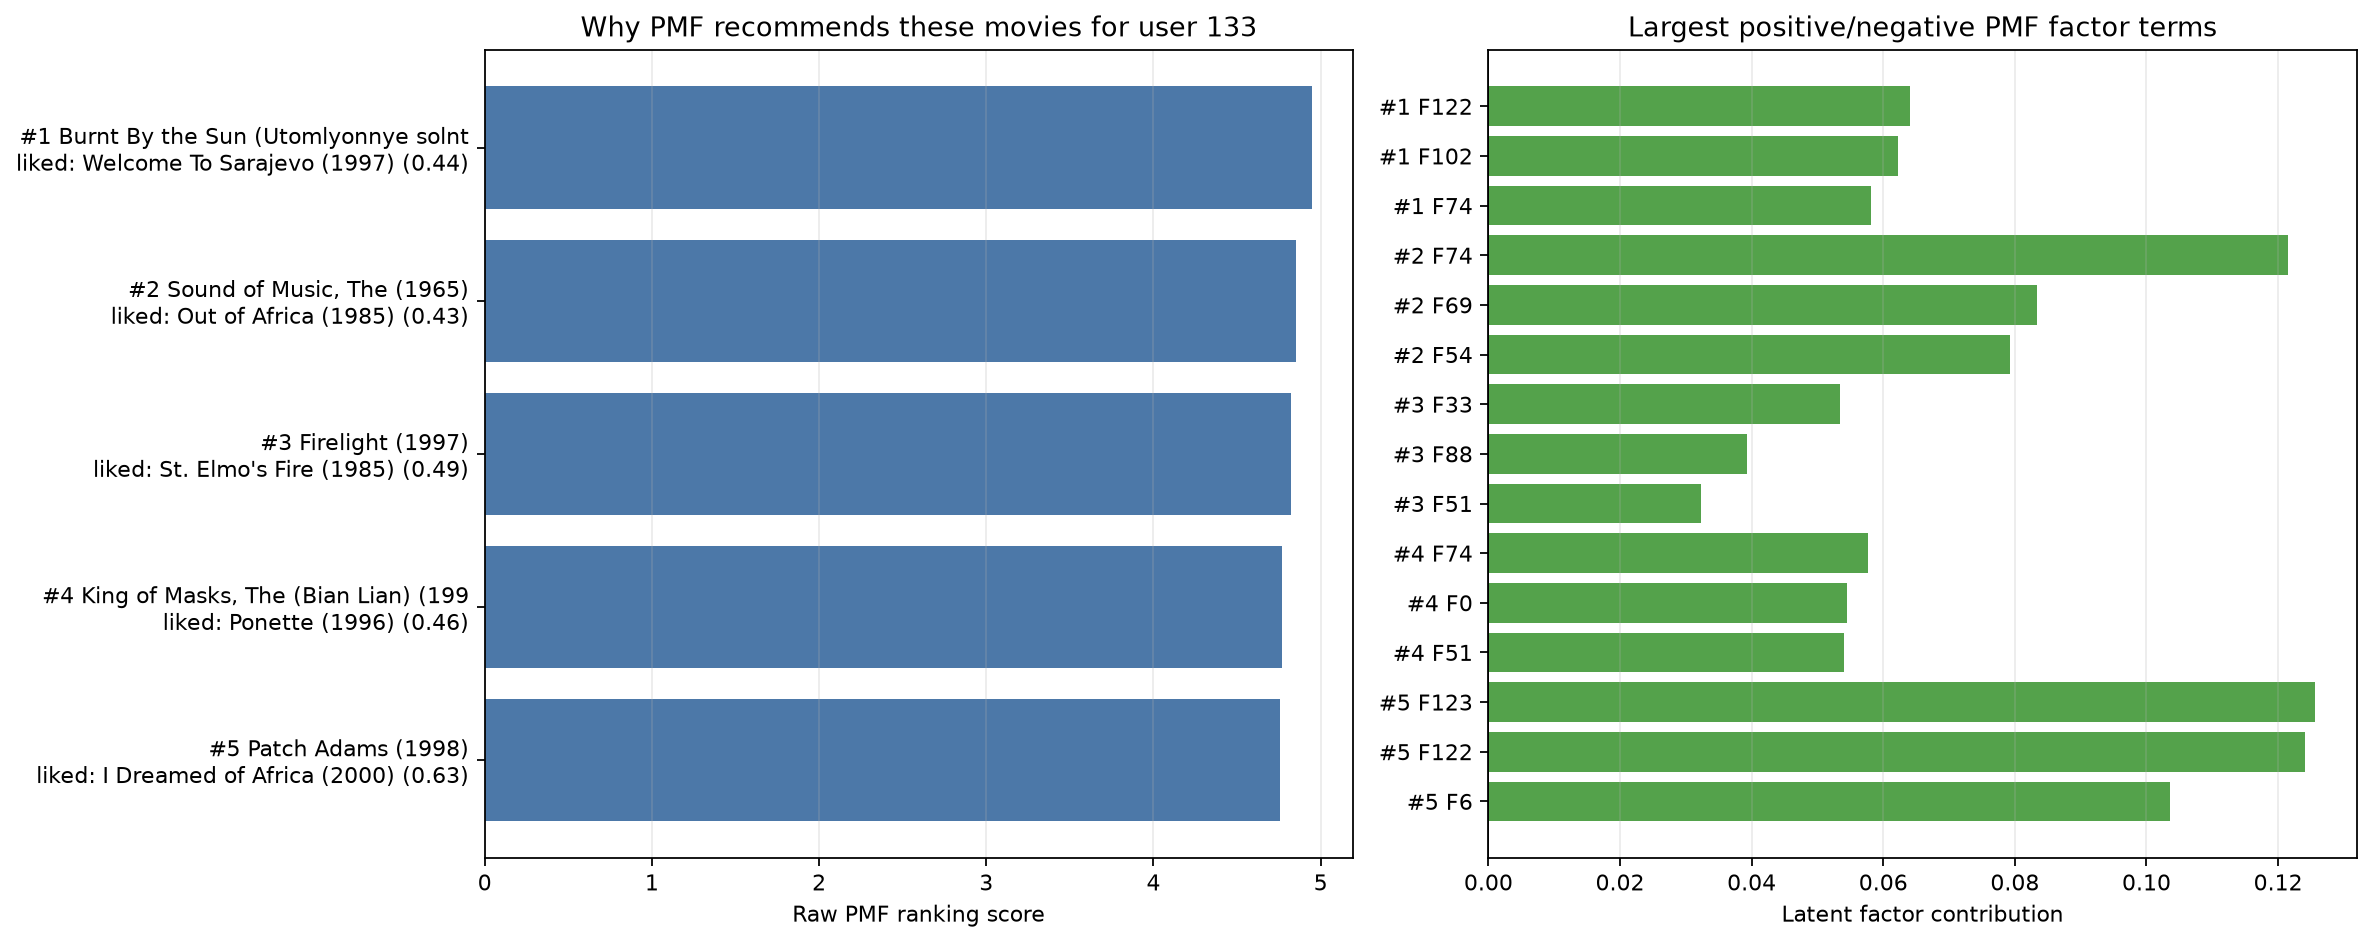

In [13]:
for row in evaluated.itertuples(index=False):
    user_id = int(row.user_id)
    explanations = pd.read_csv(REPORTS / f"user_{user_id}_explanations.csv")
    max_error = explanations["reconstruction_error"].abs().max()
    print(f"User {user_id} ({row.role}) max reconstruction error: {max_error:.2e}")
    display(
        explanations.head(5)[
            [
                "recommendation_rank",
                "title",
                "raw_pmf_ranking_score",
                "global_mean_contribution",
                "user_bias_contribution",
                "item_bias_contribution",
                "total_latent_dot_product",
                "nearest_known_title",
                "nearest_known_similarity",
            ]
        ]
    )
    display(Image(filename=str(REPORTS / f"user_{user_id}_explanation.png")))

## 14. Streamlit/artifact overview

The Streamlit app reads saved artifacts and exposes four sections:
recommendations, local explanations, model evaluation, and global latent
factors. It accepts manual user ID input, reports unknown IDs gracefully, and
does not train or tune models at app startup.

In [14]:
artifact_list = [
    "baseline_tuning.json",
    "model_metrics.json",
    "rmse_comparison.png",
    "predicted_vs_actual.png",
    "pmf_convergence.png",
    "pmf_factor_interpretation.csv",
    "pmf_factor_genre_profiles.csv",
    "pmf_latent_factor_heatmap.png",
    "pmf_movie_similarities.csv",
    "evaluated_users.json",
]
artifact_table = pd.DataFrame(
    {
        "artifact": artifact_list,
        "exists": [(REPORTS / name).exists() for name in artifact_list],
    }
)
display(artifact_table)

,artifact,exists
0,baseline_tuning.json,True
1,model_metrics.json,True
2,rmse_comparison.png,True
3,predicted_vs_actual.png,True
4,pmf_convergence.png,True
5,pmf_factor_interpretation.csv,True
6,pmf_factor_genre_profiles.csv,True
7,pmf_latent_factor_heatmap.png,True
8,pmf_movie_similarities.csv,True
9,evaluated_users.json,True


## 15. Limitations

Latent factors are not objectively semantic labels; their interpretation is
descriptive and depends on movies and genres at both poles. The chosen PMF
factor count lies at the searched factor boundary, so larger factors might be
worth investigating in future work, but this audit pass intentionally does
not retune the stable PMF grid. Interaction-level splitting means selected
audit users have train and held-out rows, not isolated train-only/test-only
identities.